# Download and prep NISAR data

This shows how the NISAR data is downloaded and assembled into an Xarray data cube. 

In [5]:
from shapely.geometry import box 
import py3dep 
import rasterio
from rasterio.enums import Resampling
import geopandas as gpd

import sys
import os
from pathlib import Path

# import from this repo 
project_root = str(Path(os.getcwd()).parent)
if project_root not in sys.path:
    sys.path.append(project_root)

%load_ext autoreload
%autoreload 2
from scripts.download import download_nisar, build_cube, download_nisar_gslc
from scripts.layers import get_nlcd_layers 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First, we setup logging to get useful information and error messages. 

In [5]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True 
)

The track, frame, start and end dates are all known based on out study area. 

In [16]:
track = 128
frame = 69
start = '2025-12-01'
end = '2026-04-30'
proc_code = 'P05023'

data_dir = "../data/"
area_file = data_dir + "aso/er_20260318/ASO_EastRiver_2026Mar18_swe_50m.tif"

with rasterio.open(area_file) as src:
    bounds = src.bounds         
    crs = src.crs
shp = gpd.GeoDataFrame(geometry=[box(*bounds)], crs=crs)

out = data_dir + f"nisar/east_river/strack{str(track).zfill(3)}_frame{str(frame).zfill(3)}"
layers = ['unwrapped_phase', 'coherence_unwrapped', # 80 m interferogram 
            'wrapped_phase', 'coherence_wrapped',  # 20 m interferogram 
            'incidence_angle', 'perpendicular_baseline',
            'reference_slant_range', 'secondary_slant_range'] # for spatial coherence  

gslc_layers = ['backscatter', 'NEBZ'] # for thermal coherence 

A function in scripts/download.py does the heavy lifting. If the files already exist, they'll be skipped. 

In [17]:
###################### downloads nisar data #######################
(grans, files) = download_nisar(
    track=track,
    frame=frame,
    start_date=start,
    end_date=end,
    aoi=shp,
    layers=layers,
    output_dir=out,
    crid=proc_code
)

###################### downloads nisar data #######################
(grans, files) = download_nisar_gslc(
    track=track,
    frame=frame,
    start_date=start,
    end_date=end,
    aoi=shp,
    layers=gslc_layers,
    output_dir=out,
    crid=proc_code
)

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/tzlocal/utils.py:39: UserWarning: Timezone offset does not match system offset: 0 != -21600. Please, check your config files.
  warnings.warn(msg)


KeyboardInterrupt: 

Once it's downloaded, we can get a list of all the files that we have. 

In [18]:
files = [item.resolve() for item in Path(data_dir + f'nisar/east_river/track{str(track).zfill(3)}_frame{str(frame).zfill(3)}').rglob('*')]
files

[PosixPath('/bsuscratch/julialober/coherence_data/nisar/east_river/track128_frame069/NISAR_L2_PR_GUNW_014_128_D_069_015_4000_SH_20260307T020614_20260307T020649_20260319T020615_20260319T020649_P05023_N_F_J_001_unwrapped_phase.tif'),
 PosixPath('/bsuscratch/julialober/coherence_data/nisar/east_river/track128_frame069/NISAR_L2_PR_GUNW_012_128_D_069_014_4000_SH_20260211T020613_20260211T020648_20260307T020614_20260307T020649_P05023_N_F_J_001_wrapped_phase.tif'),
 PosixPath('/bsuscratch/julialober/coherence_data/nisar/east_river/track128_frame069/NISAR_L2_PR_GUNW_006_128_D_069_007_4000_SH_20251201T020610_20251201T020645_20251213T020610_20251213T020645_P05023_N_F_J_001_reference_slant_range.tif'),
 PosixPath('/bsuscratch/julialober/coherence_data/nisar/east_river/track128_frame069/NISAR_L2_PR_GUNW_007_128_D_069_008_4000_SH_20251213T020610_20251213T020645_20251225T020611_20251225T020646_P05023_N_F_J_001_secondary_slant_range.tif'),
 PosixPath('/bsuscratch/julialober/coherence_data/nisar/east_r

Build some data cubes from the tif files. 

In [19]:

####################### builds coherence xarrays #######################
wrapped_files = [f for f in files if "coherence_wrapped" in str(f)]
unwrapped_files = [f for f in files if "coherence_unwrapped" in str(f)]
inc_files = [f for f in files if "incidence_angle" in str(f)]

nisar_20m = build_cube(wrapped_files, "coherence", utc_offset_hours=-7)     # 20 m grid
nisar_80m = build_cube(unwrapped_files, "coherence", utc_offset_hours=-7)  # 80 m grid
nisar_inc = build_cube(inc_files, "inc_angle", utc_offset_hours=-7)


Next, add a DEM and NLCD canopy cover layer. 

In [20]:
####################### adds nlcd and dem data #######################
# --- Wrapped dataset (20 m grid) ---
crs_20m = nisar_20m.rio.crs
aoi_20m = box(*nisar_20m.rio.bounds())

nlcd_20m = get_nlcd_layers(tile_aoi=aoi_20m, crs=crs_20m, tile_ref_grid=nisar_20m)

dem_20m = py3dep.get_dem(geometry=aoi_20m, resolution=20, crs=crs_20m)
dem_20m = dem_20m.rio.write_crs(dem_20m.rio.crs).rio.reproject_match(nisar_20m, resampling=Resampling.bilinear)

nisar_20m = nisar_20m.merge(nlcd_20m)
nisar_20m['elevation'] = dem_20m

# --- Unwrapped dataset (80 m grid) ---
crs_80m = nisar_80m.rio.crs
aoi_80m = box(*nisar_80m.rio.bounds())

nlcd_80m = get_nlcd_layers(tile_aoi=aoi_80m, crs=crs_80m, tile_ref_grid=nisar_80m)

aoi_dem = aoi_80m.buffer(1000)
dem_80m = py3dep.get_dem(geometry=aoi_dem, resolution=80, crs=crs_80m)
dem_80m = dem_80m.rio.write_crs(dem_80m.rio.crs).rio.reproject_match(nisar_80m, resampling=Resampling.bilinear)

nisar_80m = nisar_80m.merge(nlcd_80m)
nisar_80m['elevation'] = dem_80m

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge

Save the zarrs. 

In [21]:
####################### saves zarrs #######################
nisar_20m.to_zarr(data_dir + f'nisar/zarrs/track{str(track).zfill(3)}_frame{str(frame).zfill(3)}/obs_20m.zarr', mode="w")
nisar_80m.to_zarr(data_dir + f'nisar/zarrs/track{str(track).zfill(3)}_frame{str(frame).zfill(3)}/obs_80m.zarr', mode="w")

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=17, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/bsuhome/julialober/miniforge3/

In [28]:
import xarray as xr

track = 128
frame = 69

nisar_20m = xr.open_zarr(data_dir + f'nisar/zarrs/track{str(track).zfill(3)}_frame{str(frame).zfill(3)}/obs_20m.zarr')
nisar_80m = xr.open_zarr(data_dir + f'nisar/zarrs/track{str(track).zfill(3)}_frame{str(frame).zfill(3)}/obs_80m.zarr')

Plot some of the data, so we know what we are working with. 

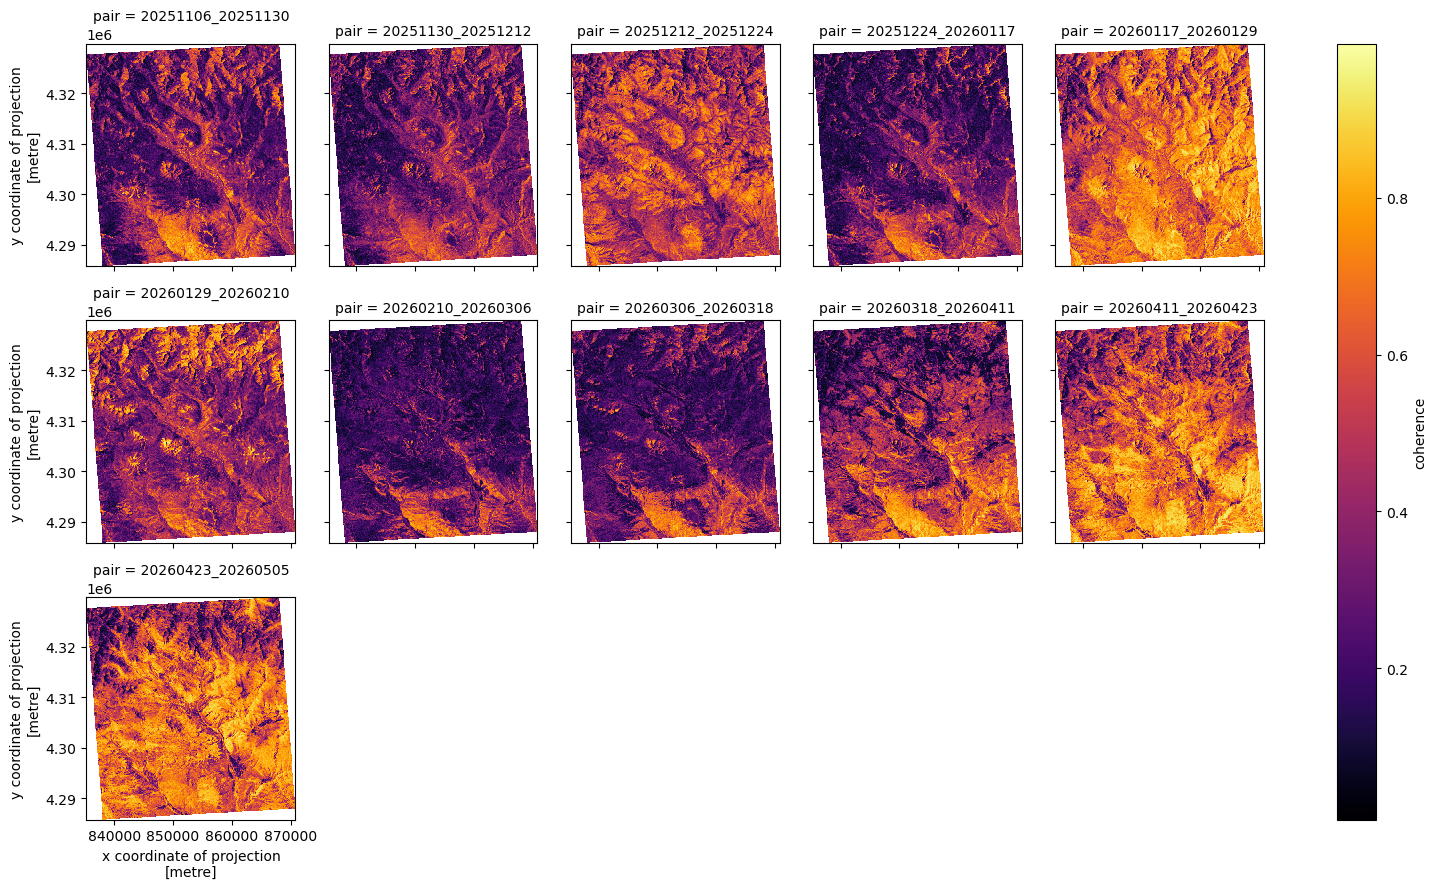

In [29]:
nisar_80m['coherence'].plot(col='pair', col_wrap=5, cmap='inferno')
nisar_20m['coherence'].plot(col='pair', col_wrap=5, cmap='inferno')